# Model training controls

In [2]:
import joblib
import optuna
from pathlib import Path
from acm.utils.modules import get_class_from_module

import matplotlib.pyplot as plt
%matplotlib inline

In [58]:
study_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/trained_models/study/')
stat_name = 'ds_xiqg'

## Stydy visualizations

### 1- TPCF

In [59]:
study = joblib.load(study_dir / f'{stat_name}.pkl')
print(f'Best trial for {stat_name}: {study.best_trial.number}')
trial = study.best_trial
print(f'  Value: {trial.value}')
print('  Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

Best trial for ds_xiqg: 81
  Value: 0.0005202646716497838
  Params: 
    learning_rate: 0.00550592520674234
    weight_decay: 7.357030408928419e-05
    n_layers: 4
    n_hidden: 577
    dropout_rate: 6.61361305774052e-05


In [49]:
optuna.visualization.plot_optimization_history(study)

In [50]:
optuna.visualization.plot_slice(study)

In [51]:
optuna.visualization.plot_param_importances(study)

In [52]:
optuna.visualization.plot_parallel_coordinate(study)

## Model errors

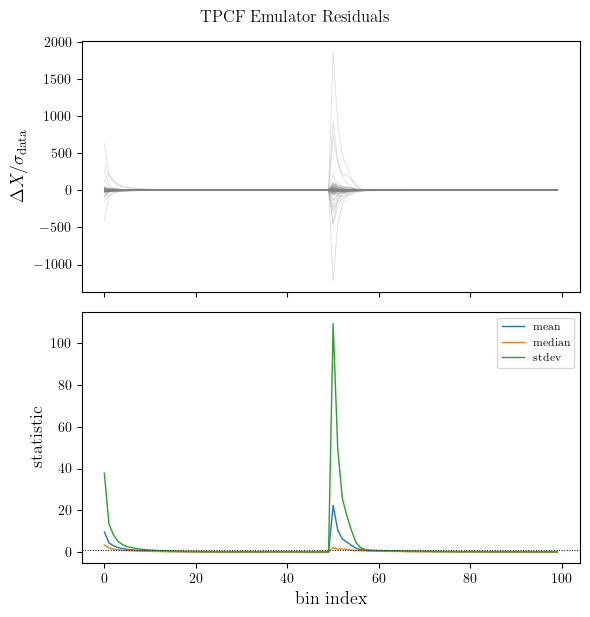

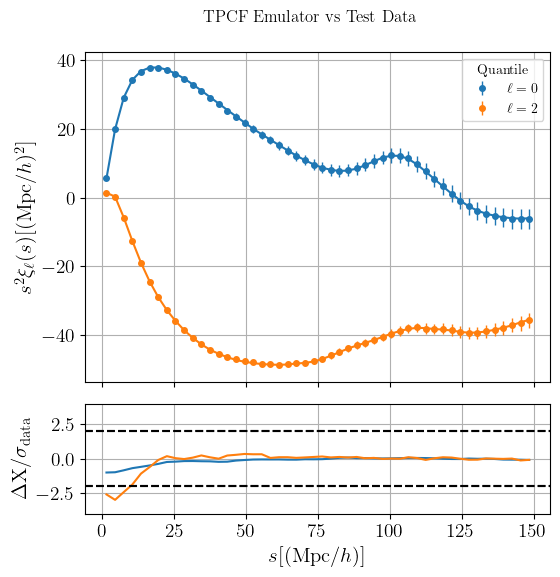

In [ ]:
obs = get_class_from_module('acm.observables.bgs', stat_name)()
fig, ax = obs.plot_emulator_residuals(figsize=(6,6))
fig.suptitle(f'{stat_name.upper()} Emulator Residuals', y=1.02);

obs.select_filters = dict(cosmo_idx=0, hod_idx=0, ells=0)
fig, ax = obs.plot_observable(model_params=obs.x)
ax[0].legend(title='Quantile')
fig.suptitle(f'{stat_name.upper()} Emulator vs Test Data', y=0.95);

# Model sensitivity

We fix the parameters value and vary one at a time to see the impact of each parameter in the model predictions.

In [73]:
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from acm.utils.modules import get_class_from_module
from sunbird.inference.priors import get_priors, Bouchard25

%config InlineBackend.figure_format = 'retina'

cosmo_params = ['omega_cdm', 'omega_b', 'sigma8_m', 'n_s', 'nrun', 'N_ur', 'w0_fld', 'wa_fld']
hod_params = ['logM_cut', 'logM_1', 'alpha', 'kappa', 'sigma', 'alpha_c', 'alpha_s', 's', 'A_cen', 'A_sat', 'B_cen', 'B_sat']

In [84]:
def get_model_sensitivity(observable, ranges: dict, n: int = 100) -> tuple:
    """
    Get model predictions by varying one parameter at a time within given ranges.

    Parameters
    ----------
    observable : acm.observables.base.Observable
        The observable object with model prediction capabilities.
    ranges : dict
        Dictionary with parameter names as keys and (min, max) tuples as values.
    n : int
        Number of points to sample for each parameter variation.

    Returns
    -------
    param_predictions : dict
        Dictionary with parameter names as keys and arrays of model predictions as values.
    param_variations : dict
        Dictionary with parameter names as keys and arrays of varied parameter values as values.

    Raises
    ------
    ValueError
        If observable.x is not a 1D array.
    """
    if len(observable.x.shape) > 1:
        raise ValueError("Observable x should be 1D array of parameter values. Check observable filters.")
    
    param_predictions = {}
    param_variations = {}
    for param in observable.x_names:
        param_range = ranges[param]
        
        # Make an array of the parameter values with varying value
        varied_values = np.linspace(param_range[0], param_range[1], n)
        param_x = np.repeat(observable.x.values, n).reshape(-1, n).T
        param_x[:, observable.x_names.index(param)] = varied_values
        
        predictions = observable.get_model_prediction(param_x)
        
        param_predictions[param] = predictions
        param_variations[param] = varied_values
    
    return param_predictions, param_variations

def plot_tpcf_sensitivity(
    param_predictions: dict, 
    param_variations: dict, 
    obs, 
    param_names: list, 
    labels: list[str] = None, 
    **kwargs
) -> plt.Figure:
    """
    Plot the sensitivity of the TPCF model predictions to parameter variations.

    Parameters
    ----------
    param_predictions : dict
        Predicted TPCF values for each parameter variation, as a dictionary of arrays.
    param_variations : dict
        Varied parameter values for each parameter, as a dictionary of arrays.
    obs : acm.observables.base.Observable
        The observable object used for predictions.
    param_names : list
        List of parameter names to plot.
    labels : dict, optional
        Dictionary mapping parameter names to labels.
    **kwargs
        Additional keyword arguments to pass to the plot function.

    Returns
    -------
    plt.Figure
        The matplotlib figure containing the sensitivity plots.
    """
    if labels is None:
        labels = {param: param for param in param_names}
    ncols = int(np.ceil(len(param_names)/2))
    nrows = 2
    fig = plt.figure(figsize=(5*ncols, 5*nrows))
    subfigs = fig.subfigures(nrows, ncols, wspace=0.07)
    cmap = cm.RdBu
    
    for i, subfig in enumerate(np.nditer(subfigs, flags=['refs_ok'])):
        if i >= len(param_names):
            break
        
        param = param_names[i]
        subfig = subfig.item()
        ax = subfig.subplots(2, 1, sharex=True)
        divider = make_axes_locatable(ax[0])
        cax = divider.append_axes("top", size="7%", pad=0.15)
        
        var = param_variations[param]
        cmap_range = (var - min(var))
        cmap_range /= max(cmap_range)
        norm = Normalize(vmin=min(var), vmax=max(var))
        mapper = cm.ScalarMappable(cmap=cmap, norm=norm)
       
        n_var = len(var)
        s = obs.s.values
        
        for j in range(n_var):
            y = param_predictions[param][j].unstack().values
            ax[0].plot(s, y[0]*s**2, color=cmap(cmap_range[j]), **kwargs)
            ax[1].plot(s, y[1]*s**2, color=cmap(cmap_range[j]), **kwargs)
        
        # Color bar
        cbar = subfig.colorbar(mapper, cax=cax, orientation='horizontal')
        cbar.set_label(labels[param], rotation=0, labelpad=10)
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
        
        ax[0].set_xlim(s.min(), s.max())
        ax[0].set_ylabel(rf'$s^2\xi_{0}(s)\,[h^{{-2}}{{\rm Mpc}}^2]$')
        ax[1].set_ylabel(rf'$s^2\xi_{2}(s)\,[h^{{-2}}{{\rm Mpc}}^2]$')
        ax[1].set_xlabel(r'$s\,[h^{-1}{\rm Mpc}]$')
        
        subfig.subplots_adjust(hspace=0.0)
        
    return fig

def plot_ds_sensitivity(
    param_predictions: dict, 
    param_variations: dict, 
    obs, 
    param_names: list, 
    quantile: int = 0, 
    labels: list[str] = None, 
    **kwargs
) -> plt.Figure:
    """
    Plot the sensitivity of the TPCF model predictions to parameter variations.

    Parameters
    ----------
    param_predictions : dict
        Predicted TPCF values for each parameter variation, as a dictionary of arrays.
    param_variations : dict
        Varied parameter values for each parameter, as a dictionary of arrays.
    obs : acm.observables.base.Observable
        The observable object used for predictions.
    param_names : list
        List of parameter names to plot.
    quantile : int
        The quantile to plot.
    labels : dict, optional
        Dictionary mapping parameter names to labels.
    **kwargs
        Additional keyword arguments to pass to the plot function.

    Returns
    -------
    plt.Figure
        The matplotlib figure containing the sensitivity plots.
    """
    if labels is None:
        labels = {param: param for param in param_names}
    ncols = int(np.ceil(len(param_names)/2))
    nrows = 2
    fig = plt.figure(figsize=(5*ncols, 5*nrows))
    subfigs = fig.subfigures(nrows, ncols, wspace=0.07)
    cmap = cm.RdBu
    
    for i, subfig in enumerate(np.nditer(subfigs, flags=['refs_ok'])):
        if i >= len(param_names):
            break
        
        param = param_names[i]
        subfig = subfig.item()
        ax = subfig.subplots(2, 1, sharex=True)
        divider = make_axes_locatable(ax[0])
        cax = divider.append_axes("top", size="7%", pad=0.15)
        
        var = param_variations[param]
        cmap_range = (var - min(var))
        cmap_range /= max(cmap_range)
        norm = Normalize(vmin=min(var), vmax=max(var))
        mapper = cm.ScalarMappable(cmap=cmap, norm=norm)
       
        n_var = len(var)
        s = obs.s.values
        
        for j in range(n_var):
            y = param_predictions[param][j].unstack().sel(quantiles=quantile).values
            ax[0].plot(s, y[0]*s**2, color=cmap(cmap_range[j]), **kwargs)
            ax[1].plot(s, y[1]*s**2, color=cmap(cmap_range[j]), **kwargs)
        
        # Color bar
        cbar = subfig.colorbar(mapper, cax=cax, orientation='horizontal')
        cbar.set_label(labels[param], rotation=0, labelpad=10)
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
        
        ax[0].set_xlim(s.min(), s.max())
        ax[0].set_ylabel(rf'$s^2\xi_{0}(s)\,[h^{{-2}}{{\rm Mpc}}^2]$')
        ax[1].set_ylabel(rf'$s^2\xi_{2}(s)\,[h^{{-2}}{{\rm Mpc}}^2]$')
        ax[1].set_xlabel(r'$s\,[h^{-1}{\rm Mpc}]$')
        
        subfig.subplots_adjust(hspace=0.0)
        
    return fig

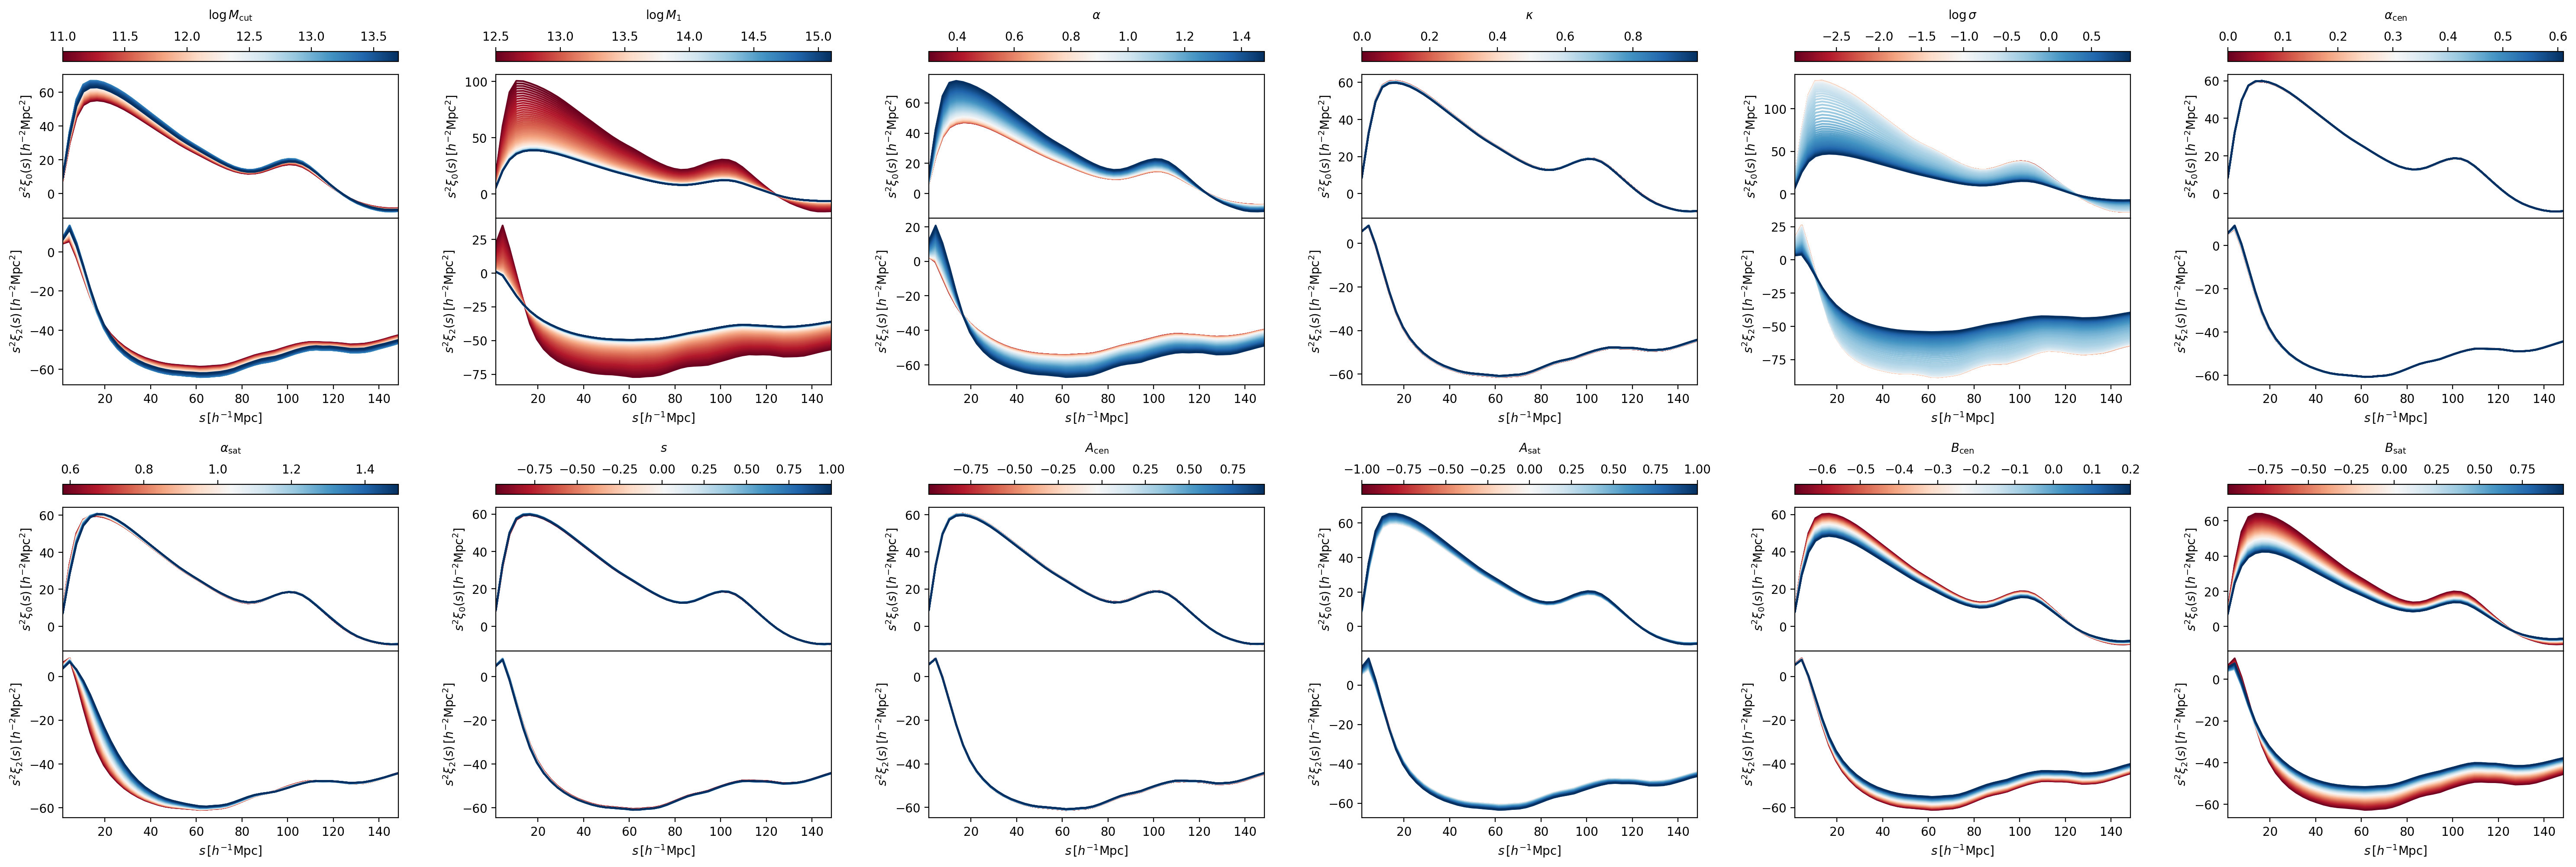

In [87]:
# TPCF
obs = get_class_from_module('acm.observables.bgs', 'tpcf')(select_filters={'cosmo_idx':0, 'hod_idx':61})
default_values = {k: v for k, v in zip(obs.x_names, obs.x.values)}
priors, ranges, labels = get_priors(hod_class=Bouchard25)

param_predictions, param_variations = get_model_sensitivity(obs, ranges)
plot_tpcf_sensitivity(param_predictions, param_variations, obs, param_names=hod_params, labels=labels);

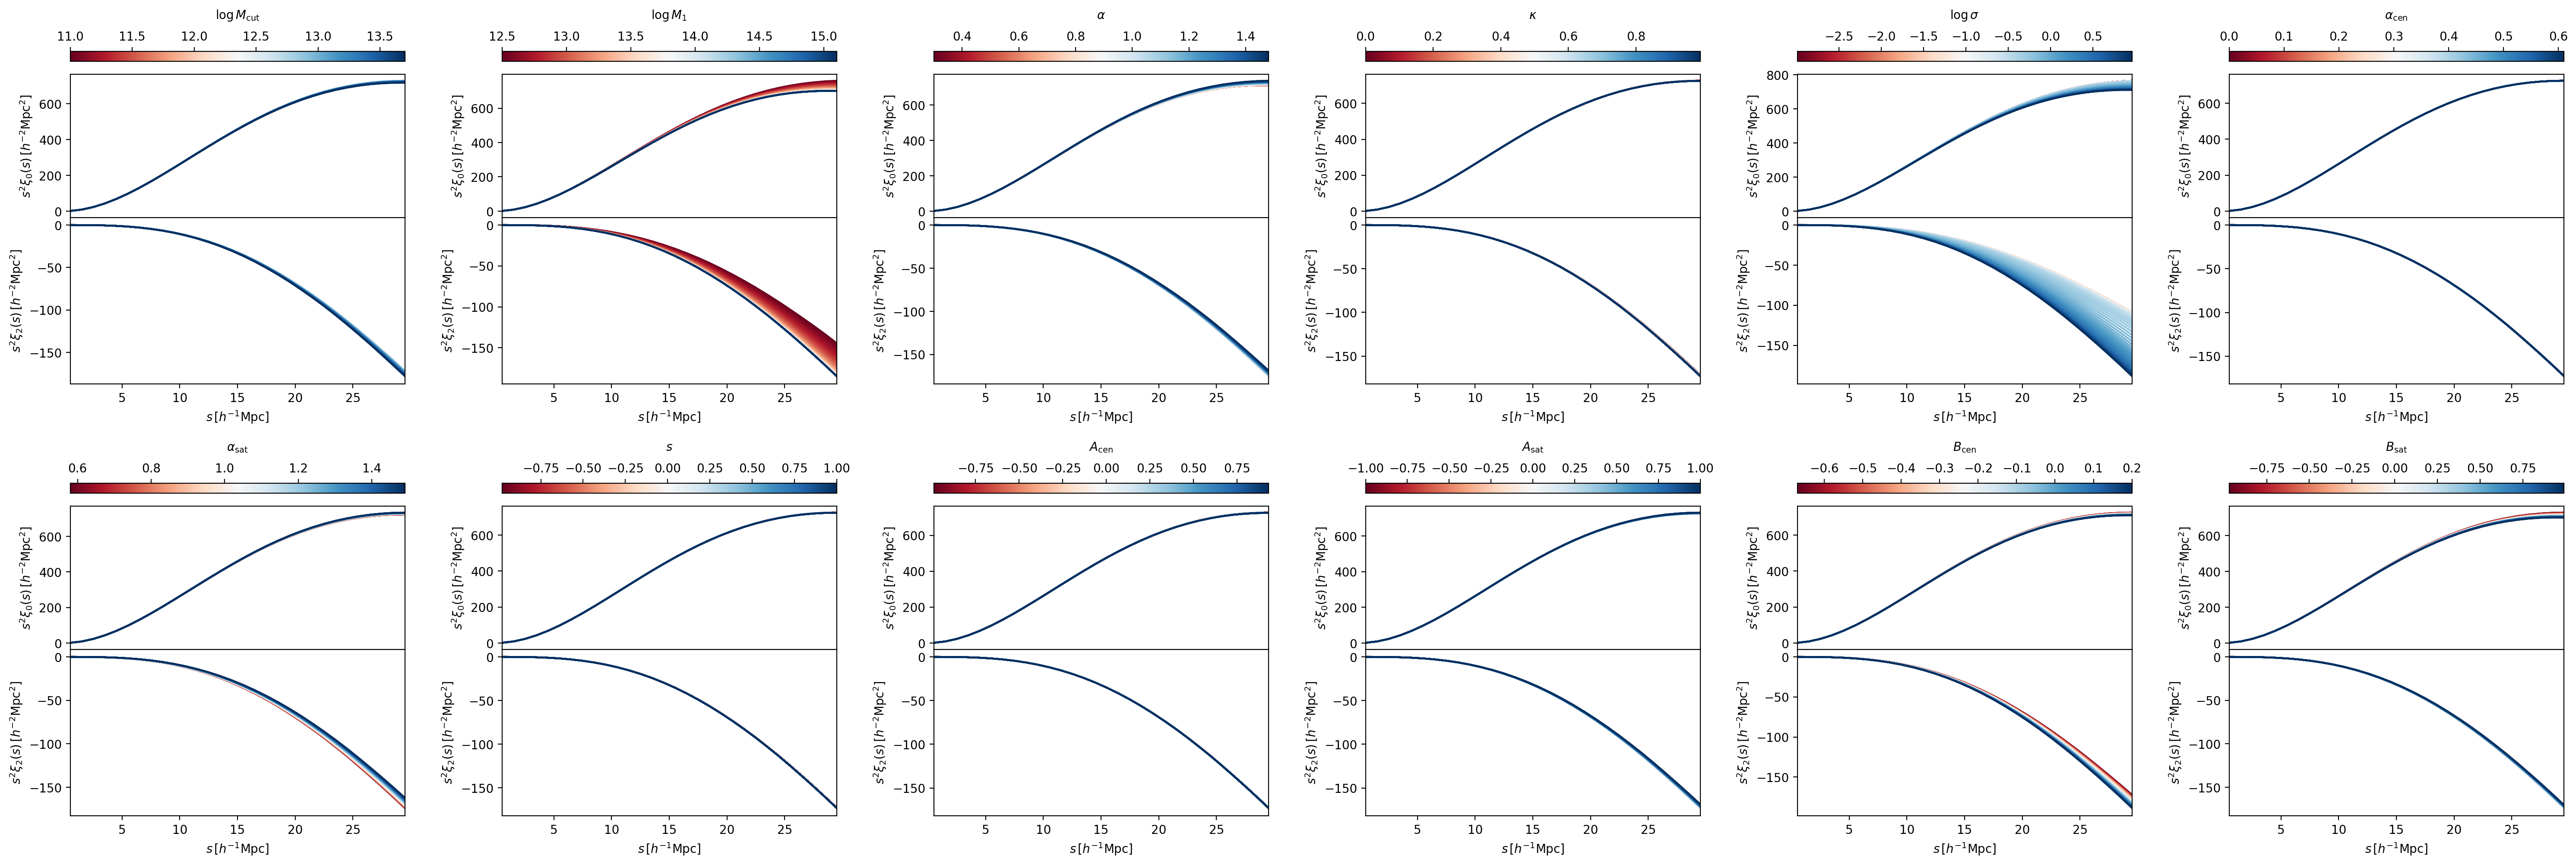

In [91]:
# DS_XIQQ
obs = get_class_from_module('acm.observables.bgs', 'ds_xiqq')(select_filters={'cosmo_idx':0, 'hod_idx':61})
default_values = {k: v for k, v in zip(obs.x_names, obs.x.values)}
priors, ranges, labels = get_priors(hod_class=Bouchard25)

param_predictions, param_variations = get_model_sensitivity(obs, ranges)
plot_ds_sensitivity(param_predictions, param_variations, obs, quantile=0, param_names=hod_params, labels=labels);